<a href="https://colab.research.google.com/github/Khalimovgeek/Kaggle_tesnorflow_trainings/blob/main/News_Category_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install tensorflow-datasets


In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models,utils,datasets
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [9]:
!cp /content/drive/MyDrive/dataset/train/train.csv /content/train.csv
!cp /content/drive/MyDrive/dataset/test/test.csv /content/test.csv

In [5]:
# train_path = '/content/drive/MyDrive/dataset/train/train.csv'
# test_path = '/content/drive/MyDrive/dataset/test/test.csv'

# train_path = '/content/train.csv'
# test_path = '/content/test.csv'

In [10]:

# train_dataset = tf.data.experimental.make_csv_dataset(train_path,batch_size=32,label_name='Class Index',num_parallel_reads=tf.data.AUTOTUNE)
# test_dataset = tf.data.experimental.make_csv_dataset(test_path,batch_size=32,label_name='Class Index',num_parallel_reads=tf.data.AUTOTUNE)
import pandas as pd
import tensorflow as tf

train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

train_text = (
    train_df["Title"] + " " + train_df["Description"]
).values

train_labels = train_df["Class Index"].values - 1

test_text = (
    test_df["Title"] + " " + test_df["Description"]
).values

test_labels = test_df["Class Index"].values - 1

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_text, train_labels)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_text, test_labels)
)

train_dataset = (
    train_dataset
    .shuffle(10000)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

In [11]:
for text, label in train_dataset.take(1):
    print(text[0].numpy().decode())
    print(label[0].numpy())

Bank of America Exec to Get Severance Pay Bank of America Corp. said a departing executive is eligible to collect about \$20.7 million in severance and other payments from the company.
2


In [12]:
MAX_TOKENS = 10000
SEQUNCE_LEN = 200
vectorize_layer = layers.TextVectorization(max_tokens=MAX_TOKENS,output_mode='int',output_sequence_length=SEQUNCE_LEN)


In [13]:
print(train_dataset.cardinality())

tf.Tensor(3750, shape=(), dtype=int64)


In [15]:
import time

start = time.time()

count = 0
for text, label in train_dataset:
    count += 1

print("Batches:", count)
print("Time:", time.time() - start)

Batches: 3750
Time: 1.7809357643127441


In [16]:
train_text = train_dataset.map(lambda text, label: text)
vectorize_layer.adapt(train_text)

In [17]:
print(f"Vocabulary size after adaptation: {len(vectorize_layer.get_vocabulary())}")
def create_model():

    vocab_size = len(vectorize_layer.get_vocabulary())

    model = models.Sequential([
        keras.Input(shape=(), dtype=tf.string),
        vectorize_layer,

        layers.Embedding(vocab_size, 64, mask_zero=True, input_length=SEQUNCE_LEN),

        layers.Conv1D(128, 5, padding='same', activation='relu'),
        layers.Dropout(0.2),
        layers.MaxPooling1D(),

        layers.Conv1D(256, 5, padding='same', activation='relu'),
        layers.Dropout(0.2),
        layers.GlobalAveragePooling1D(),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu'),
        layers.Dense(4, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

Vocabulary size after adaptation: 10000


In [18]:
my_model = create_model()
my_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 200, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 256)       │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 878,596 (3.35 MB)

 Trainable params: 878,596 (3.35 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)
checkpoint = keras.callbacks.ModelCheckpoint(
    "best_news_classifier.keras",
    monitor="val_loss",
    save_best_only=True
)

In [20]:
history = my_model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset,
    callbacks=[early_stop, checkpoint]

)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 40s 9ms/step - accuracy: 0.8806 - loss: 0.3412 - val_accuracy: 0.9091 - val_loss: 0.2796
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9247 - loss: 0.2246 - val_accuracy: 0.9072 - val_loss: 0.2781
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9375 - loss: 0.1829 - val_accuracy: 0.9018 - val_loss: 0.3042
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 40s 9ms/step - accuracy: 0.9482 - loss: 0.1478 - val_accuracy: 0.9028 - val_loss: 0.3628


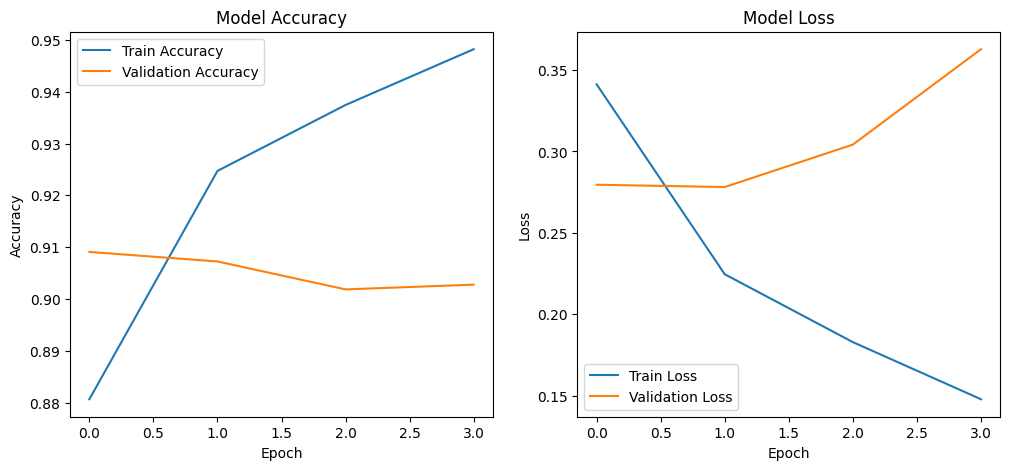

In [21]:

plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [27]:
models = keras.models.load_model('best_news_classifier.keras')
models.predict(test_dataset.take(1))
#

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


array([[4.73133214e-02, 1.52287236e-03, 8.56279671e-01, 9.48842317e-02],
       [1.82266027e-04, 4.83809174e-07, 1.31729772e-04, 9.99685645e-01],
       [8.70962963e-02, 4.91624773e-01, 2.48203631e-02, 3.96458566e-01],
       [1.70330271e-01, 4.12804812e-01, 1.83617845e-02, 3.98503095e-01],
       [2.12993085e-01, 4.03275453e-02, 7.16373548e-02, 6.75042033e-01],
       [2.17585601e-02, 4.37342009e-04, 1.31736264e-01, 8.46067846e-01],
       [2.67921685e-04, 1.17376125e-07, 5.27400116e-05, 9.99679208e-01],
       [1.89903248e-02, 1.90477464e-02, 1.55994117e-01, 8.05967808e-01],
       [2.95807600e-01, 1.05285998e-02, 1.64719865e-01, 5.28943956e-01],
       [8.75780731e-02, 5.06594358e-03, 1.46049410e-01, 7.61306524e-01],
       [1.78258715e-03, 2.18661694e-06, 8.87493268e-02, 9.09465909e-01],
       [2.95328482e-05, 1.09719600e-09, 8.69762211e-04, 9.99100685e-01],
       [5.27564087e-04, 2.43018157e-08, 8.48123282e-02, 9.14660037e-01],
       [2.74403721e-01, 7.67013873e-04, 3.39865178e

In [28]:
import tensorflow as tf

news = tf.constant([
    "Apple unveiled its latest AI-powered iPhone during today's keynote event.",
    "Manchester United defeated Liverpool 3-1 in the Premier League.",
    "The United Nations approved a new climate change resolution.",
    "Tesla shares rose 8 percent after reporting record quarterly profits."
])

In [33]:
predictions = my_model(news, training=False)

predicted = tf.argmax(predictions, axis=1).numpy()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [30]:
label_names = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

In [31]:
for article, pred in zip(news.numpy(), predicted):
    print("=" * 80)
    print(article.decode())
    print("Prediction:", label_names[pred])

Apple unveiled its latest AI-powered iPhone during today's keynote event.
Prediction: Sci/Tech
Manchester United defeated Liverpool 3-1 in the Premier League.
Prediction: Sports
The United Nations approved a new climate change resolution.
Prediction: World
Tesla shares rose 8 percent after reporting record quarterly profits.
Prediction: Business


In [32]:
import numpy as np

for article, probs in zip(news.numpy(), predictions.numpy()):
    print("=" * 80)
    print(article.decode())

    pred = np.argmax(probs)
    print(f"Prediction: {label_names[pred]}")

    print("\nProbabilities:")
    for name, p in zip(label_names, probs):
        print(f"{name:10}: {p:.3f}")

Apple unveiled its latest AI-powered iPhone during today's keynote event.
Prediction: Sci/Tech

Probabilities:
World     : 0.040
Sports    : 0.007
Business  : 0.044
Sci/Tech  : 0.908
Manchester United defeated Liverpool 3-1 in the Premier League.
Prediction: Sports

Probabilities:
World     : 0.030
Sports    : 0.959
Business  : 0.009
Sci/Tech  : 0.002
The United Nations approved a new climate change resolution.
Prediction: World

Probabilities:
World     : 0.481
Sports    : 0.020
Business  : 0.168
Sci/Tech  : 0.331
Tesla shares rose 8 percent after reporting record quarterly profits.
Prediction: Business

Probabilities:
World     : 0.010
Sports    : 0.001
Business  : 0.936
Sci/Tech  : 0.054


In [34]:
label_names = ["World", "Sports", "Business", "Sci/Tech"]

for texts, labels in test_dataset.take(1):
    predictions = models.predict(texts, verbose=0)
    predicted = tf.argmax(predictions, axis=1)

    for text, true_label, pred in zip(texts.numpy(), labels.numpy(), predicted.numpy()):
        print("=" * 80)
        print(text.decode())
        print(f"True      : {label_names[true_label]}")
        print(f"Predicted : {label_names[pred]}")

Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.
True      : Business
Predicted : Business
The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing for the  #36;10 million Ansari X Prize, a contest for\privately funded suborbital space flight, has officially announced the first\launch date for its manned rocket.
True      : Sci/Tech
Predicted : Sci/Tech
Ky. Company Wins Grant to Study Peptides (AP) AP - A company founded by a chemistry researcher at the University of Louisville won a grant to develop a method of producing better peptides, which are short chains of amino acids, the building blocks of proteins.
True      : Sci/Tech
Predicted : Sports
Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful 

In [35]:
news = tf.constant([
    "Google announced a new AI chip for data centers.",
    "India defeated Australia by six wickets in the ODI series."
])

predictions = models(news, training=False)
predicted = tf.argmax(predictions, axis=1).numpy()

label_names = ["World", "Sports", "Business", "Sci/Tech"]

for article, pred in zip(news.numpy(), predicted):
    print(article.decode())
    print("Prediction:", label_names[pred])

Google announced a new AI chip for data centers.
Prediction: Sci/Tech
India defeated Australia by six wickets in the ODI series.
Prediction: World


In [36]:
pred = models(news, training=False)

for article, probs in zip(news.numpy(), pred.numpy()):
    print(article.decode())

    for name, p in zip(label_names, probs):
        print(f"{name:10}: {p:.3f}")

    print()

Google announced a new AI chip for data centers.
World     : 0.019
Sports    : 0.003
Business  : 0.136
Sci/Tech  : 0.842

India defeated Australia by six wickets in the ODI series.
World     : 0.406
Sports    : 0.383
Business  : 0.132
Sci/Tech  : 0.078

